In [3]:
# ==============================================================================
# MINOR PROJECT: CREDIT RISK OPTIMIZATION
# Objective: Predict loan default risk using supervised machine learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('credit_risk_dataset.csv')

print("Data successfully loaded!")
print("Rows aur Columns:", df.shape)

Data successfully loaded!
Rows aur Columns: (32581, 12)


/tmp/ipykernel_4313/4104172292.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='viridis')
/tmp/ipykernel_4313/4104172292.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_intent', y='loan_amnt', data=df, palette='Set2')


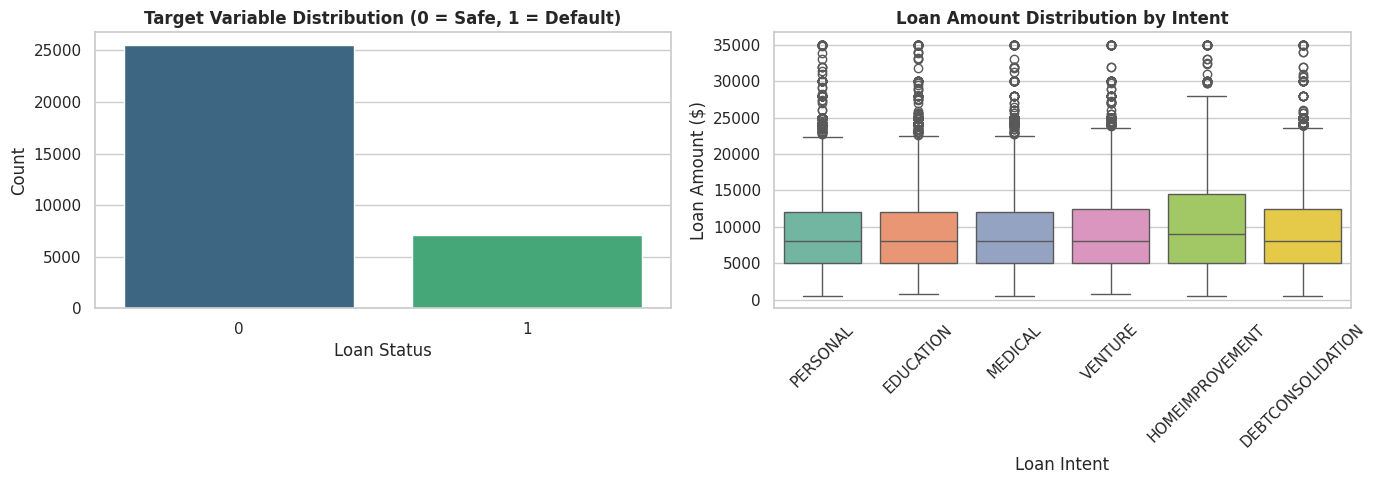

In [4]:
# ==============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================

# Set visual style for professional charts
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Plot 1: Distribution of the Target Variable (Class Imbalance check)
plt.subplot(1, 2, 1)
sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Target Variable Distribution (0 = Safe, 1 = Default)', fontsize=12, fontweight='bold')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# Plot 2: Loan Intent vs. Loan Amount
plt.subplot(1, 2, 2)
sns.boxplot(x='loan_intent', y='loan_amnt', data=df, palette='Set2')
plt.title('Loan Amount Distribution by Intent', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Loan Intent')
plt.ylabel('Loan Amount ($)')

plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# DATA PREPROCESSING
# Handling Missing Values, Encoding Categorical Features, and Splitting Data
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- Preprocessing Started ---\n")

# 0. Remove Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found and removed: {duplicates}")
df = df.drop_duplicates()

# 1. Handle Missing Values using the Median (Robust to outliers)
print(f"Missing 'person_emp_length' before: {df['person_emp_length'].isnull().sum()}")
print(f"Missing 'loan_int_rate' before: {df['loan_int_rate'].isnull().sum()}")

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print(f"Missing values after imputation: {df.isnull().sum().sum()} \n")

# 2. Feature Encoding (Convert text categories to numerical)
# drop_first=True prevents the dummy variable trap (multicollinearity)
df_encoded = pd.get_dummies(df, drop_first=True)

# Ensure all boolean columns created by get_dummies are converted to integers (1/0)
for col in df_encoded.select_dtypes(include=['boolean', 'bool']).columns:
    df_encoded[col] = df_encoded[col].astype(int)

# 3. Define Features (X) and Target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 4. Train-Test Split (80% Training, 20% Testing)
# stratify=y ensures the same proportion of defaults in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Data Shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data Shape: X={X_test.shape}, y={y_test.shape}\n")

# 5. Feature Scaling (Standardizing numerical ranges)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete!")

--- Preprocessing Started ---

Duplicates found and removed: 165
Missing 'person_emp_length' before: 887
Missing 'loan_int_rate' before: 3095
Missing values after imputation: 0 

Training Data Shape: X=(25932, 22), y=(25932,)
Testing Data Shape: X=(6484, 22), y=(6484,)

Preprocessing Complete!


In [6]:
# ==============================================================================
# CLASS BALANCING (SMOTE)
# Addressing the imbalance in the target variable to prevent model bias
# ==============================================================================

# Install imbalanced-learn if not already present in the environment
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

# Initialize and apply SMOTE only to the TRAINING data to prevent data leakage
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Target Class Distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nTarget Class Distribution AFTER SMOTE:")
print(y_train_smote.value_counts())
print("\nData is now perfectly balanced for training.")

Target Class Distribution BEFORE SMOTE:
loan_status
0    20261
1     5671
Name: count, dtype: int64

Target Class Distribution AFTER SMOTE:
loan_status
0    20261
1    20261
Name: count, dtype: int64

Data is now perfectly balanced for training.


--- Logistic Regression Evaluation ---
Accuracy  : 0.8157 (Overall correctness)
Precision : 0.5571 (Accuracy of positive predictions)
Recall    : 0.7673 (Ability to find all positive cases)
F1-Score  : 0.6455 (Harmonic mean of Precision and Recall)



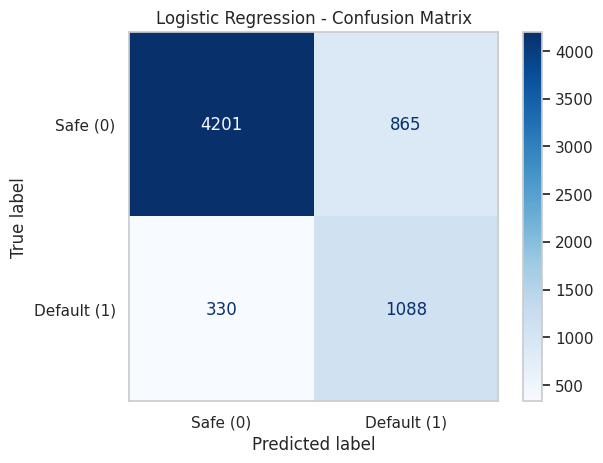

--- Random Forest Evaluation ---
Accuracy  : 0.9269 (Overall correctness)
Precision : 0.9062 (Accuracy of positive predictions)
Recall    : 0.7426 (Ability to find all positive cases)
F1-Score  : 0.8163 (Harmonic mean of Precision and Recall)



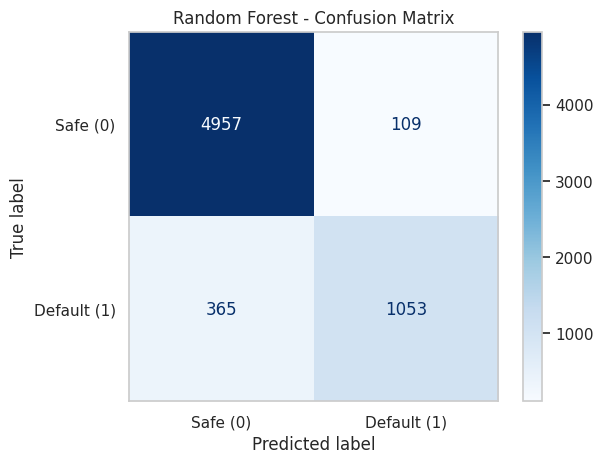

In [7]:
# ==============================================================================
# MODEL DEVELOPMENT & EVALUATION
# Training Logistic Regression and Random Forest, evaluating against rubric metrics
# ==============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X_test_data, y_true, model_name):
    """Function to predict and print professional evaluation metrics."""
    # Generate predictions
    y_pred = model.predict(X_test_data)

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print Results
    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy  : {acc:.4f} (Overall correctness)")
    print(f"Precision : {prec:.4f} (Accuracy of positive predictions)")
    print(f"Recall    : {rec:.4f} (Ability to find all positive cases)")
    print(f"F1-Score  : {f1:.4f} (Harmonic mean of Precision and Recall)\n")

    # Display Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Default (1)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.grid(False) # Turn off grid for the matrix visualization
    plt.show()

# ---------------------------------------------------------
# Model 1: Logistic Regression (Baseline Model)
# ---------------------------------------------------------
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)
evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")

# ---------------------------------------------------------
# Model 2: Random Forest (Advanced Ensemble Model)
# ---------------------------------------------------------
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_smote, y_train_smote)
evaluate_model(rf_clf, X_test_scaled, y_test, "Random Forest")

/tmp/ipykernel_4313/229232112.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='magma')


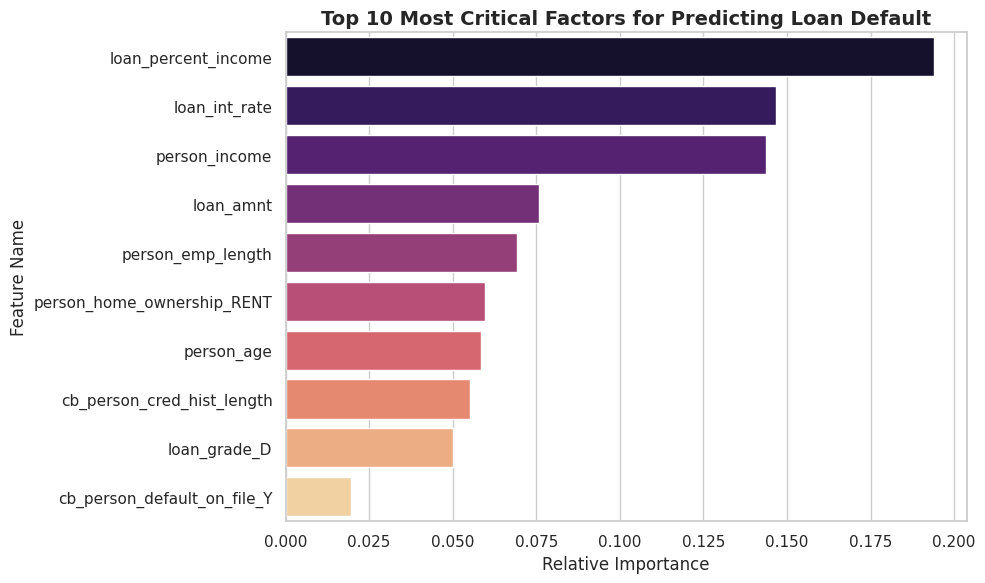

In [8]:
# ==============================================================================
# FEATURE IMPORTANCE (Model Interpretability)
# Discovering which variables most strongly predict loan defaults
# ==============================================================================

# Extract feature importances from the trained Random Forest model
importances = rf_clf.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort it by importance
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot the Top 10 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='magma')
plt.title('Top 10 Most Critical Factors for Predicting Loan Default', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

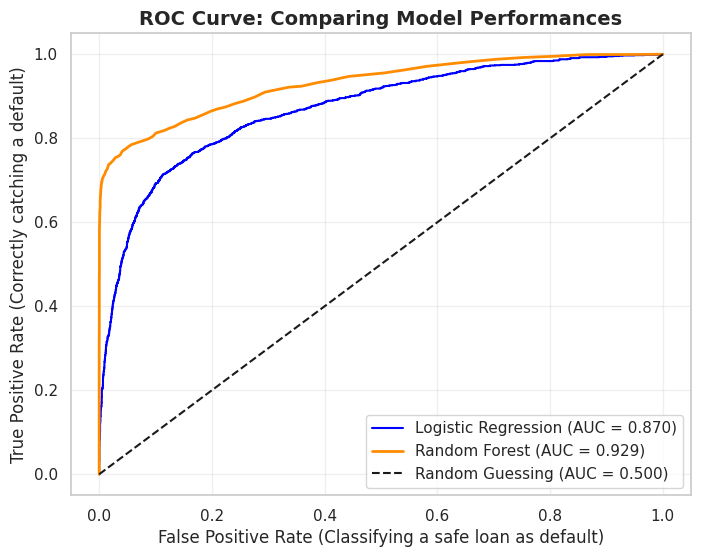

In [9]:
# ==============================================================================
# ROC-AUC CURVE
# Visualizing the trade-off between True Positives and False Positives
# ==============================================================================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

# Calculate ROC for Logistic Regression
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', color='blue')

# Calculate ROC for Random Forest
y_prob_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='darkorange', linewidth=2)

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')

plt.title('ROC Curve: Comparing Model Performances', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (Classifying a safe loan as default)')
plt.ylabel('True Positive Rate (Correctly catching a default)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
import pickle

# 1. Exporting the Logistic Regression Model
try:
    with open('logistic_regression_model.pkl', 'wb') as file1:
        # Note: 'log_reg' ki jagah apna actual variable name check kar lena
        pickle.dump(log_reg, file1)
    print("Success: Logistic Regression model exported as 'logistic_regression_model.pkl'.")
except Exception as e:
    print(f"Error saving Logistic Regression model: {e}")

# 2. Exporting the Random Forest Model
try:
    with open('random_forest_model.pkl', 'wb') as file2:
        # Note: 'rf_model' ki jagah apna actual variable name check kar lena
        pickle.dump(rf_clf, file2)
    print("Success: Random Forest model exported as 'random_forest_model.pkl'.")
except Exception as e:
    print(f"Error saving Random Forest model: {e}")

Success: Logistic Regression model exported as 'logistic_regression_model.pkl'.
Success: Random Forest model exported as 'random_forest_model.pkl'.
